### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# EXPLORACION DE DATOS (EDA)

In [2]:
tienda.info()
tienda2.info()
tienda3.info()
tienda4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns 

In [3]:
tienda.describe()
tienda2.describe()
tienda3.describe()
tienda4.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,2.358000e+03,2358.000000,2358.000000,2358.000000,2358.000000,2358.000000
mean,4.403629e+05,23459.457167,3.995759,2.896098,5.413519,-74.774597
std,5.687556e+05,30279.100836,1.403063,2.730393,2.376728,1.199749
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.340000e+04,2900.000000,3.000000,1.000000,4.609710,-75.563590
50%,2.094500e+05,10950.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.342250e+05,33300.000000,5.000000,4.000000,6.251840,-74.081750
max,2.902200e+06,154700.000000,5.000000,18.000000,11.544440,-67.923900


In [5]:
tienda['Producto'].value_counts().head(10)
tienda2['Producto'].value_counts().head(10)
tienda3['Producto'].value_counts().head(10)
tienda4['Producto'].value_counts().head(10)


Producto
Cama box                     62
Cubertería                   59
Dashboards con Power BI      56
Cama king                    56
Carrito de control remoto    55
Mesa de comedor              55
Mesa de noche                55
Smart TV                     54
Bloques de construcción      54
Pandereta                    52
Name: count, dtype: int64

# 1. Análisis de facturación



In [6]:
import pandas as pd

# Cargar los CSV y guardarlos en una lista
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

tiendas_nombradas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']

ingresos = [df['Precio'].sum() for df in tiendas]

tiendas_precios = list(zip(tiendas_nombradas, ingresos))
print(tiendas_precios)

print("Ingresos por tienda:")
for i in range(len(tiendas_nombradas)):
    print(f"{tiendas_nombradas[i]}: ${ingresos[i]:,.2f}")


# ordenar los ingresos de mayor a menor
tiendas_precios.sort(key=lambda x: x[1], reverse=True)
print("\nIngresos por tienda (ordenados de mayor a menor):")
for tienda, ingreso in tiendas_precios:
    print(f"{tienda}: ${ingreso:,.2f}")

print(f"la tienda con mayor ingreso es {tiendas_precios[0][0]} con ${tiendas_precios[0][1]:,.2f}")

[('tienda1', np.float64(1150880400.0)), ('tienda2', np.float64(1116343500.0)), ('tienda3', np.float64(1098019600.0)), ('tienda4', np.float64(1038375700.0))]
Ingresos por tienda:
tienda1: $1,150,880,400.00
tienda2: $1,116,343,500.00
tienda3: $1,098,019,600.00
tienda4: $1,038,375,700.00

Ingresos por tienda (ordenados de mayor a menor):
tienda1: $1,150,880,400.00
tienda2: $1,116,343,500.00
tienda3: $1,098,019,600.00
tienda4: $1,038,375,700.00
la tienda con mayor ingreso es tienda1 con $1,150,880,400.00


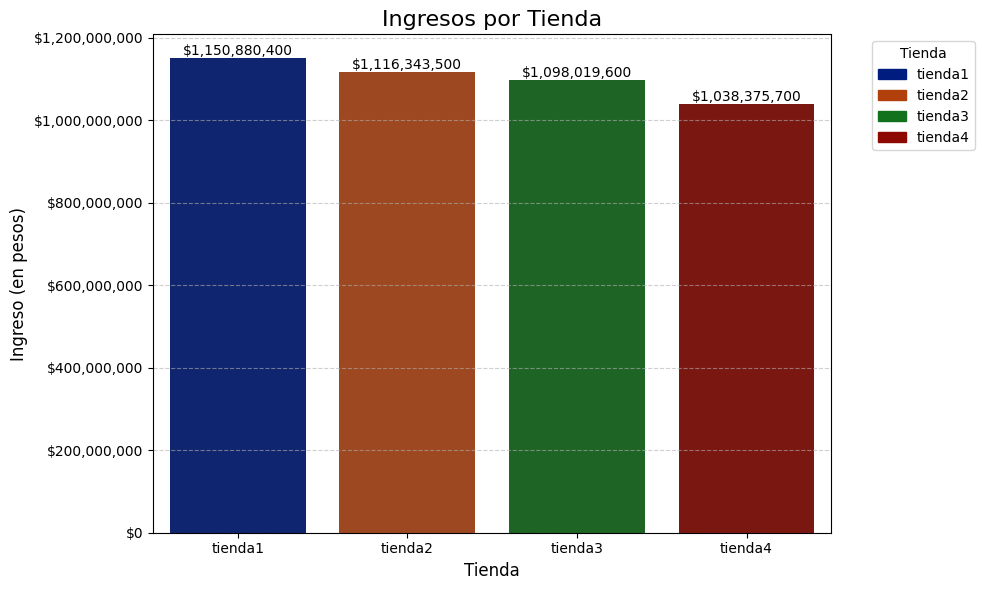

In [37]:
import matplotlib.patches as mpatches

# Colores personalizados para cada tienda
tiendas = df_ingresos['Tienda']
colores = sns.color_palette('dark', len(tiendas))
colores_dict = dict(zip(tiendas, colores))

# Crear gráfico
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='Tienda', y='Ingreso', data=df_ingresos, hue= 'Tienda', palette=colores_dict)
                   
# Formatear eje Y
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Agregar etiquetas
for i, row in df_ingresos.iterrows():
    plt.text(i, row['Ingreso'] + 500, f"${int(row['Ingreso']):,}", ha='center', va='bottom', fontsize=10)

# Crear leyenda manual
patches = [mpatches.Patch(color=colores_dict[tienda], label=tienda) for tienda in tiendas]
plt.legend(handles=patches, title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')

# Personalización
plt.title('Ingresos por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingreso (en pesos)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


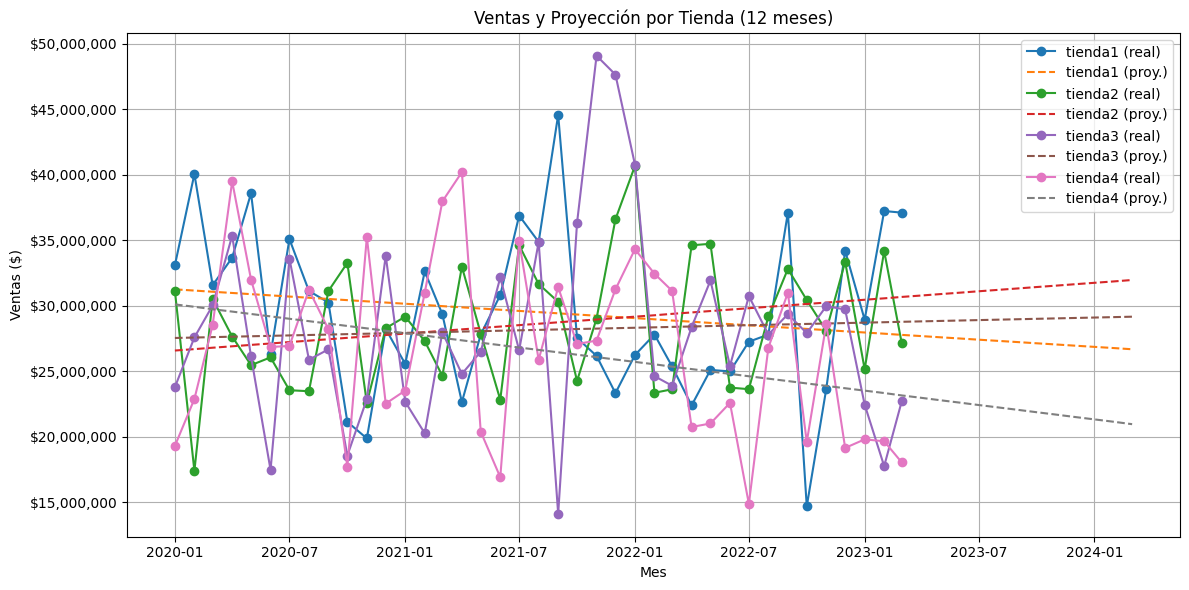

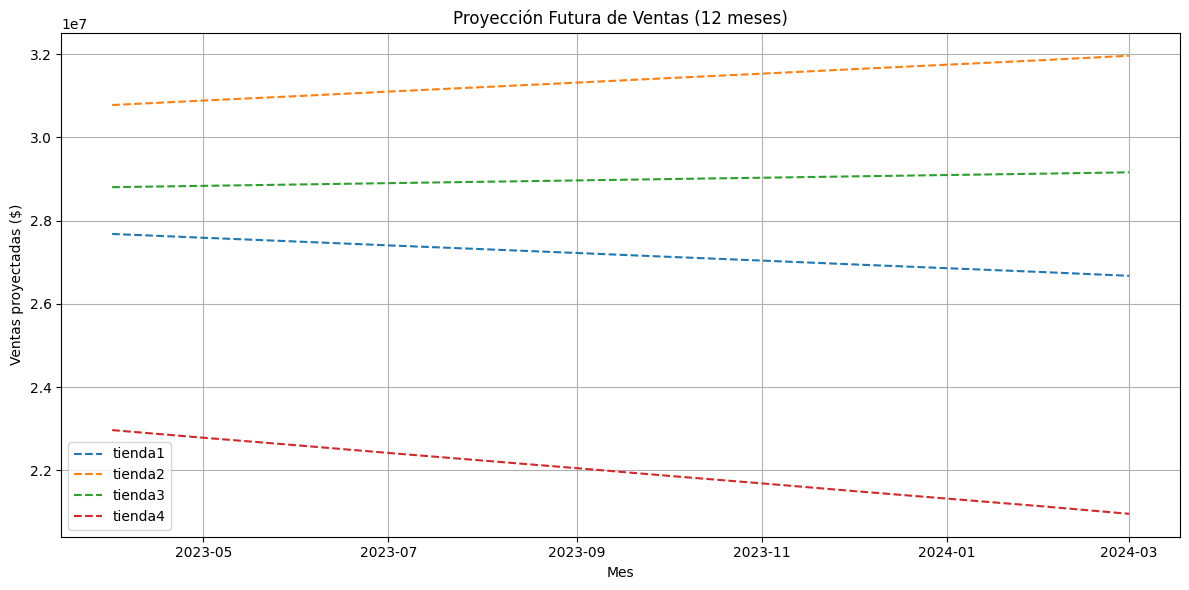

In [12]:
import pandas as pd
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Lista con los DataFrames ya leídos
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

tiendas_nombradas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
tiendas_mensual = []

for df in tiendas:
    df['Fecha de Compra'] = pd.to_datetime(df['Fecha de Compra'], dayfirst=True)
    df['Mes'] = df['Fecha de Compra'].dt.to_period('M').dt.to_timestamp()
    df_mes = df.groupby('Mes')['Precio'].sum().reset_index()
    tiendas_mensual.append(df_mes)

# ----------- Gráfico 1: Datos reales + predicción combinados ----------------
plt.figure(figsize=(12, 6))
meses_futuro = 12

for i, df in enumerate(tiendas_mensual):
    nombre = tiendas_nombradas[i]
    X = np.arange(len(df)).reshape(-1, 1)
    y = df['Precio'].values

    modelo = LinearRegression()
    modelo.fit(X, y)

    futuro_X = np.arange(len(df) + meses_futuro).reshape(-1, 1)
    predicciones = modelo.predict(futuro_X)

    fechas_futuras = pd.date_range(start=df['Mes'].iloc[0], periods=len(futuro_X), freq='MS')

    plt.plot(df['Mes'], y, label=f'{nombre} (real)', marker='o')
    plt.plot(fechas_futuras, predicciones, label=f'{nombre} (proy.)', linestyle='--')
    plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.title('Ventas y Proyección por Tienda (12 meses)')
plt.xlabel('Mes')
plt.ylabel('Ventas ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------- Gráfico 2: Solo proyección futura ----------------
plt.figure(figsize=(12, 6))

for i, df in enumerate(tiendas_mensual):
    nombre = tiendas_nombradas[i]
    X = np.arange(len(df)).reshape(-1, 1)
    y = df['Precio'].values

    modelo = LinearRegression()
    modelo.fit(X, y)

    futuro_X = np.arange(len(df), len(df) + meses_futuro).reshape(-1, 1)
    predicciones = modelo.predict(np.arange(len(df) + meses_futuro).reshape(-1, 1))

    fechas_futuras = pd.date_range(start=df['Mes'].iloc[0], periods=len(df) + meses_futuro, freq='MS')
    fechas_pred = fechas_futuras[-meses_futuro:]

    plt.plot(fechas_pred, predicciones[-meses_futuro:], label=f'{nombre}', linestyle='--')

plt.title('Proyección Futura de Ventas (12 meses)')
plt.xlabel('Mes')
plt.ylabel('Ventas proyectadas ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Ventas por categoría

In [40]:
import pandas as pd

# Cargar los CSV y guardarlos en una lista
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

In [ ]:
# Nombres de las tiendas
nombres_tiendas = ["tienda1", "tienda2", "tienda3", "tienda4"]

# Recorrer las tiendas y mostrar categorías más populares
for nombre, df in zip(nombres_tiendas, tiendas):
    print(f"\n Categorías más vendidas en {nombre}:")
    categorias = df.groupby("Categoría del Producto").size().sort_values(ascending=False)
    print(categorias.head(10))


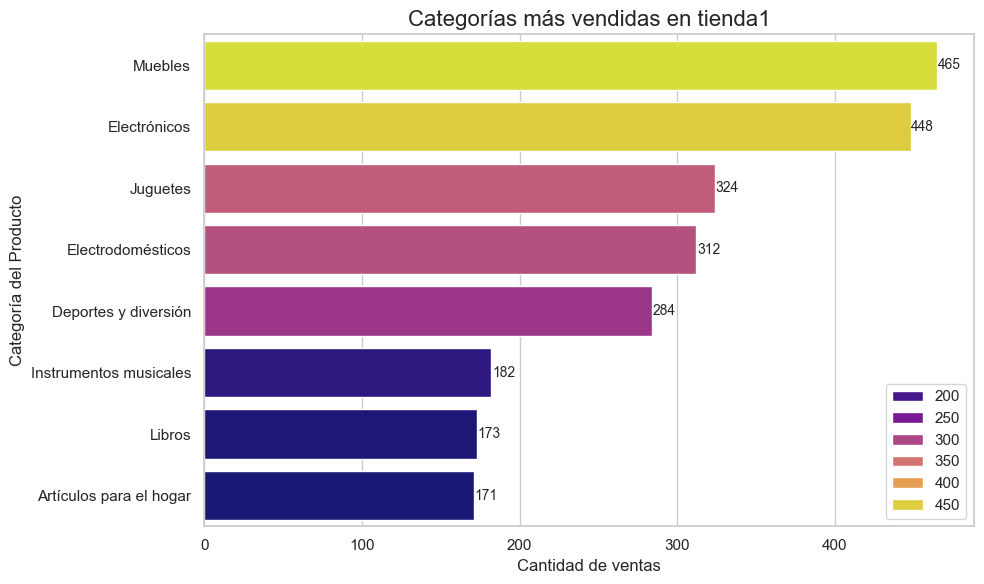

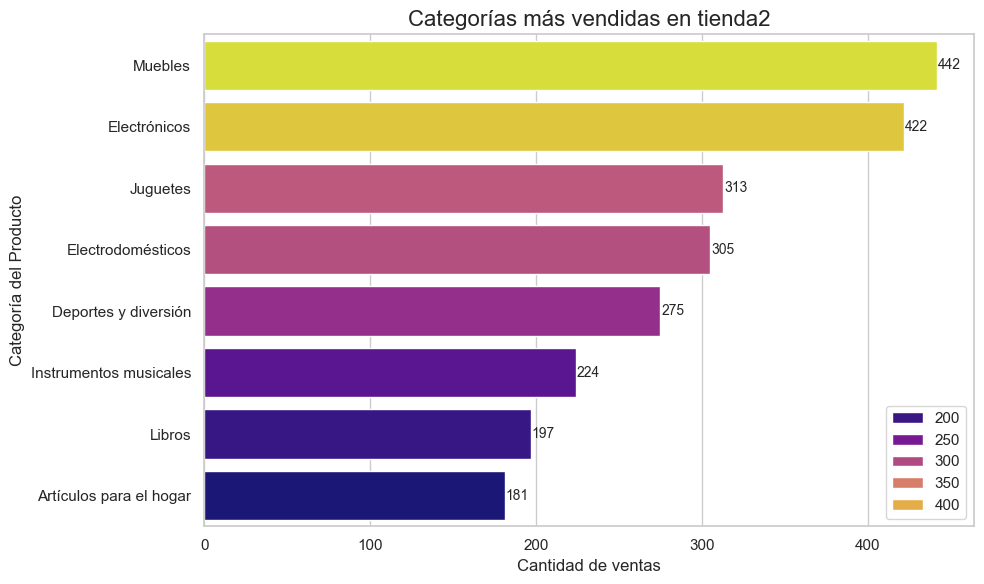

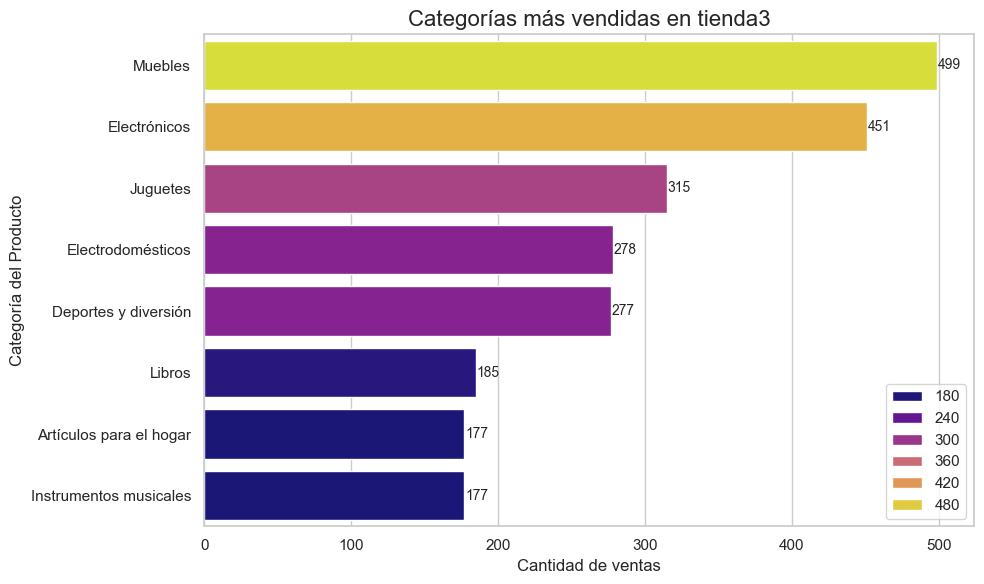

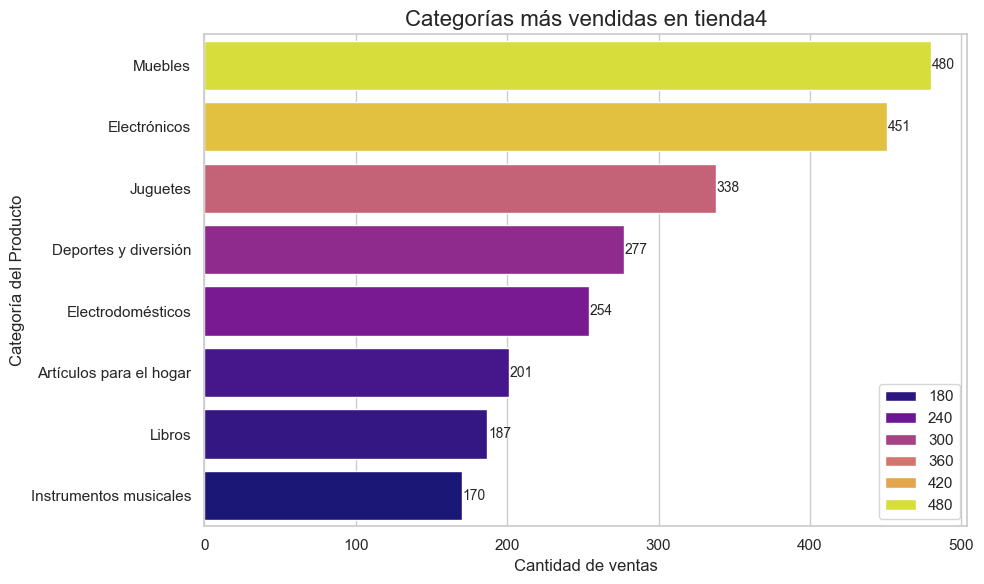

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set(style="whitegrid")

# Recorrer tiendas y graficar
for nombre, df in zip(nombres_tiendas, tiendas):
    # Agrupar por categoría
    categorias = df.groupby("Categoría del Producto").size().sort_values(ascending=False).head(10)

    # Crear figura
    plt.figure(figsize=(10, 6))
    sns.barplot(x=categorias.values, y=categorias.index,hue = categorias.values , palette="plasma")
    
    # Títulos y etiquetas
    plt.title(f'Categorías más vendidas en {nombre}', fontsize=16)
    plt.xlabel('Cantidad de ventas')
    plt.ylabel('Categoría del Producto')

    # Mostrar valores al final de cada barra
    for i, (valor, categoria) in enumerate(zip(categorias.values, categorias.index)):
        plt.text(valor + 0.5, i, str(valor), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()


# 3. Calificación promedio de la tienda


In [54]:
import pandas as pd

# Cargar los CSV y guardarlos en una lista
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

In [ ]:
nombres_tiendas = ["tienda1", "tienda2", "tienda3", "tienda4"]
promedios_calificacion = []

calificaciones = nombre,tienda, zip(nombres_tiendas, tiendas)
for nombre, df in zip(nombres_tiendas, tiendas):
    print(f"\n Calificaciones de productos en {nombre}:")
    promedio = df["Calificación"].mean()
    print(f"Promedio de calificación en {nombre}: {promedio:.2f}")
# Lista para guardar (tienda, promedio)
    promedios_calificacion.append((nombre, promedio))
    
print(promedios_calificacion)

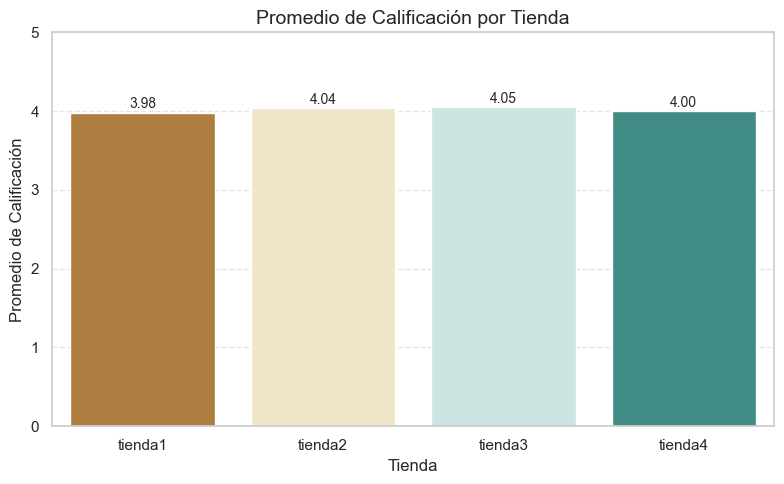

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_calificaciones = pd.DataFrame(promedios_calificacion, columns=["Tienda", "Promedio Calificación"])

# Estilo
sns.set(style="whitegrid")

# Crear gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x="Tienda", y="Promedio Calificación", data=df_calificaciones,hue = 'Tienda', palette="BrBG")

# Agregar valores sobre las barras
for i, row in df_calificaciones.iterrows():
    plt.text(i, row["Promedio Calificación"] + 0.02, f"{row['Promedio Calificación']:.2f}", ha='center', va='bottom', fontsize=10)

# Personalización
plt.title("Promedio de Calificación por Tienda", fontsize=14)
plt.ylabel("Promedio de Calificación")
plt.ylim(0, 5)  # Asumiendo escala de 1 a 5
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [75]:
import pandas as pd

# Cargar los CSV y guardarlos en una lista
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

nombres_tiendas = ["tienda1", "tienda2", "tienda3", "tienda4"]

In [ ]:
# Recorrer cada tienda y mostrar los más y menos vendidos
for nombre, df in zip(nombres_tiendas, tiendas):
    print(f"\n Productos más vendidos en {nombre}:")
    productos_mas_vendidos = df['Producto'].value_counts().head(5)
    print(productos_mas_vendidos)
    
    print(f"\n Productos menos vendidos en {nombre}:")
    productos_menos_vendidos = df['Producto'].value_counts().tail(5)
    print(productos_menos_vendidos)
# import pdb; pdb.set_trace()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráfico general
sns.set(style="whitegrid")

# Recorrer cada tienda
for nombre, df in zip(nombres_tiendas, tiendas):
    # Productos más y menos vendidos
    productos_mas_vendidos = df['Producto'].value_counts().head(5)
    productos_menos_vendidos = df['Producto'].value_counts().nsmallest(5)

    # --- Gráfico: Productos más vendidos ---
    plt.figure(figsize=(10, 5))
    sns.barplot(x=productos_mas_vendidos.values, y=productos_mas_vendidos.index,hue = productos_mas_vendidos.index,  palette="Greens_r")
    plt.title(f'Productos MÁS vendidos en {nombre}')
    plt.xlabel('Cantidad de ventas')
    plt.ylabel('Producto')
    
    # Agregar etiquetas al final de cada barra
    for i, (valor, producto) in enumerate(zip(productos_mas_vendidos.values, productos_mas_vendidos.index)):
        plt.text(valor + 0.5, i, str(valor), va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

    # --- Gráfico: Productos menos vendidos ---
    plt.figure(figsize=(10, 5))
    sns.barplot(x=productos_menos_vendidos.values, y=productos_menos_vendidos.index,hue = productos_menos_vendidos.index, palette="Reds")
    plt.title(f'Productos MENOS vendidos en {nombre}')
    plt.xlabel('Cantidad de ventas')
    plt.ylabel('Producto')
    
    # Agregar etiquetas al final de cada barra
    for i, (valor, producto) in enumerate(zip(productos_menos_vendidos.values, productos_menos_vendidos.index)):
        plt.text(valor + 0.5, i, str(valor), va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# 5. Envío promedio por tienda

In [84]:
import pandas as pd

# Cargar los CSV y guardarlos en una lista
tiendas = [
    pd.read_csv(url),   # tienda 1
    pd.read_csv(url2),  # tienda 2
    pd.read_csv(url3),  # tienda 3
    pd.read_csv(url4)   # tienda 4
]

nombres_tiendas = ["tienda1", "tienda2", "tienda3", "tienda4"]

In [ ]:
# Costo por envio
for nombre,df in zip(nombres_tiendas, tiendas):
    promedio_envio = df['Costo de envío'].mean()
    print(f"\nCosto promedio de envío en {nombre}: ${promedio_envio:,.2f}")
    

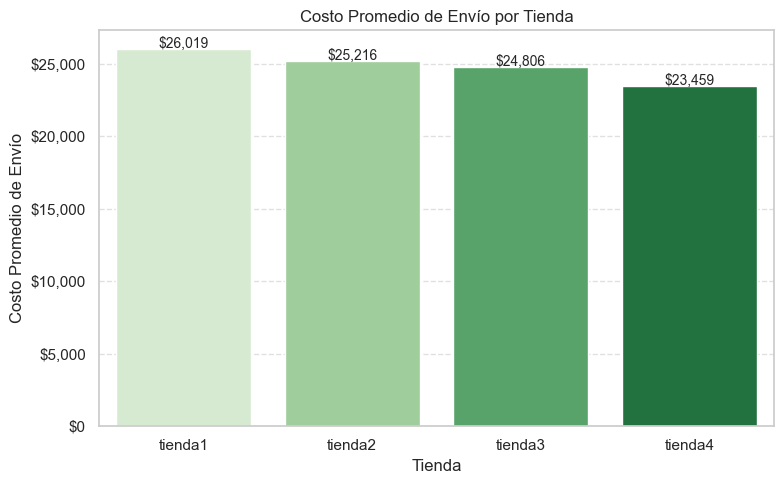

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular los promedios
promedios_envio = [(nombre, df['Costo de envío'].mean()) for nombre, df in zip(nombres_tiendas, tiendas)]

# Crear DataFrame
import pandas as pd
df_promedios = pd.DataFrame(promedios_envio, columns=['Tienda', 'Costo Promedio'])

# Graficar
plt.figure(figsize=(8, 5))
sns.barplot(data=df_promedios, x='Tienda', y='Costo Promedio',hue = 'Tienda', palette='Greens')

# Formato de eje Y
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Agregar etiquetas encima de cada barra
for i, row in df_promedios.iterrows():
    plt.text(i, row['Costo Promedio'] + 100, f"${row['Costo Promedio']:,.0f}", ha='center', fontsize=10)

plt.title("Costo Promedio de Envío por Tienda")
plt.ylabel("Costo Promedio de Envío")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
